In [1]:
import os, json, shutil, math
from pathlib import Path

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from tqdm import tqdm
from glob import glob
import pandas as pd

import contextlib
from scipy.ndimage import affine_transform  # aproximação nnunet: rotação + scaling em _augment

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

# #fix E1: caminhos alinhados com o restante do projeto
SPLITS_DIR = Path(r"D:\master_experiments\data\splits\BraTS2020_Splits")
META_PATH  = SPLITS_DIR / "splits_metadata.json"

MOME_BASE = Path(r"D:\master_experiments\models_configs\MoME_BraTS2020")
MOME_CKPT = MOME_BASE / "checkpoints"
MOME_PRED = MOME_BASE / "predictions_test"
MOME_LOGS = MOME_BASE / "logs"

for p in [MOME_BASE, MOME_CKPT, MOME_PRED, MOME_LOGS]:
    p.mkdir(parents=True, exist_ok=True)

MODS      = ["flair", "t1", "t1ce", "t2"]
N_EXPERTS = len(MODS)   # = 4
N_CLASSES = 4           # 0=bg 1=nec 2=ede 3=enh
DEPTH     = 3
BASE_CH   = 32
PATCH     = 128         # aproximação nnunet: era 96, alinha com plano nnUNet 3d_fullres
NUM_ITERS_PER_EPOCH = 250  # aproximação nnunet: iterações fixas por época (era ≈ len(train_ids))

FILE_ENDING = ".nii.gz"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NW = 0 if os.name == "nt" else 4

print("Device:", DEVICE)
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name} | VRAM: {props.total_memory/1e9:.1f} GB")

Device: cuda
GPU: NVIDIA GeForce RTX 4070 SUPER | VRAM: 12.9 GB


In [2]:
with open(META_PATH, "r", encoding="utf-8") as f:
    meta = json.load(f)

train_ids = meta["ids"]["train"]
val_ids   = meta["ids"]["val"]
test_ids  = meta["ids"]["test"]

print(f"Train: {len(train_ids)} | Val: {len(val_ids)} | Test: {len(test_ids)}")

Train: 245 | Val: 52 | Test: 53


In [3]:
def case_dir(split_name: str, case_id: str) -> Path:
    return SPLITS_DIR / split_name / case_id

def find_file(folder: Path, key: str) -> Path:
    for cand in [folder / f"{key}.nii.gz", folder / f"{key}.nii"]:
        if cand.exists():
            return cand
    cands = sorted(list(folder.glob(f"*{key}*.nii*")))
    if key == "t1":
        cands = [c for c in cands if "t1ce" not in c.name.lower()]
    if not cands:
        raise FileNotFoundError(f"{key} not found in {folder}")
    return cands[0]

def load_arr(p):
    return np.asanyarray(nib.load(str(p)).dataobj)

def norm01(x, p1=1, p99=99):
    # Mantida para visualização (display em cmap='gray' precisa de [0,1])
    x = x.astype(np.float32)
    lo, hi = np.percentile(x, [p1, p99])
    if hi <= lo:
        return np.zeros_like(x, dtype=np.float32)
    return np.clip((x - lo) / (hi - lo), 0, 1)

def norm_zscore_fg(x):  # aproximação nnunet: z-score dentro da máscara de foreground (cérebro)
    x = x.astype(np.float32)
    mask = x > 0
    if mask.sum() == 0:
        return np.zeros_like(x, dtype=np.float32)
    mean = float(x[mask].mean())
    std  = float(x[mask].std()) + 1e-8
    out  = (x - mean) / std
    out[~mask] = 0.0  # background fixo em 0 (mesma convenção do nnUNet)
    return out

def dice_score(a, b):
    inter = np.count_nonzero(a & b)
    denom = np.count_nonzero(a) + np.count_nonzero(b)
    return 1.0 if denom == 0 else (2.0 * inter / denom)

def pick_best_slice(seg, axis=2):
    counts = np.sum(seg > 0, axis=tuple(i for i in range(3) if i != axis))
    return int(np.argmax(counts))

def load_brats_seg(path):
    data = load_arr(path).astype(np.int16)
    data[data == 4] = 3
    return data

In [4]:
class BraTSPatchDataset(Dataset):

    def __init__(self, ids_list, split_name,
                 mode="all", mod_idx=None,
                 patch=PATCH, augment=True,
                 num_iterations=None):  # aproximação nnunet: iters fixos por época
        assert mode in ("all", "single_expert")
        if mode == "single_expert":
            assert mod_idx is not None, \
                "mod_idx obrigatório para mode='single_expert'"
        self.ids     = ids_list
        self.split   = split_name
        self.mode    = mode
        self.mod_idx = mod_idx
        self.patch   = patch
        self.aug     = augment
        self.num_iterations = num_iterations  # se None, usa len(ids) (modo "uma passada por época")

    def __len__(self):
        # aproximação nnunet: 250 iters fixos quando num_iterations setado
        return self.num_iterations if self.num_iterations is not None else len(self.ids)

    def _lesion_crop(self, arrays, patch):  # aproximação nnunet: 33% foreground oversample
        seg = arrays[-1]
        # 33% chance de centrar em foreground; 67% aleatório (mesma proporção do nnUNet)
        if np.random.rand() < 0.33:
            coords = np.argwhere(seg > 0)
            if len(coords) == 0:
                coords = np.argwhere(np.ones_like(seg))
        else:
            coords = np.argwhere(np.ones_like(seg))
        center = coords[np.random.randint(len(coords))]
        half = patch // 2
        lo, hi = [], []
        for ax in range(3):
            c = int(np.clip(center[ax], half, seg.shape[ax] - half))
            lo.append(c - half)
            hi.append(c + half)
        return [a[lo[0]:hi[0], lo[1]:hi[1], lo[2]:hi[2]] for a in arrays]

    def _augment(self, imgs, seg):  # #fix M1: brilho compartilhado | aproximação nnunet: rotação + scaling
        # 1. Spatial: rotação (±30°) + scaling (0.85-1.25) no plano axial — prob 0.2
        if np.random.rand() < 0.2:
            angle = np.random.uniform(-30, 30) * np.pi / 180.0
            scale = np.random.uniform(0.85, 1.25)
            cos_a = np.cos(angle) / scale
            sin_a = np.sin(angle) / scale
            matrix = np.array([
                [1.0/scale, 0.0, 0.0],
                [0.0,  cos_a, sin_a],
                [0.0, -sin_a, cos_a],
            ], dtype=np.float64)
            shape = np.array(imgs[0].shape)
            center = (shape - 1) / 2.0
            offset = center - matrix @ center
            imgs = [affine_transform(im, matrix, offset=offset, order=1,
                                     mode='constant', cval=0).astype(np.float32) for im in imgs]
            seg  = affine_transform(seg.astype(np.int16), matrix, offset=offset, order=0,
                                    mode='constant', cval=0).astype(np.int16)

        # 2. Mirror flips por eixo
        for ax in range(3):
            if np.random.rand() > 0.5:
                imgs = [np.flip(im, axis=ax).copy() for im in imgs]
                seg  = np.flip(seg, axis=ax).copy()

        # 3. Brilho compartilhado entre modalidades + ruído independente
        bright = np.random.uniform(0.85, 1.15) if np.random.rand() > 0.5 else 1.0
        aug_imgs = []
        for im in imgs:
            im = im * bright
            if np.random.rand() > 0.5:
                im = im + np.random.normal(0, 0.05, im.shape).astype(np.float32)
            # aproximação nnunet: SEM clip — z-score não é bounded em [0,1]
            aug_imgs.append(im.astype(np.float32))
        return aug_imgs, seg

    def __getitem__(self, idx):
        # aproximação nnunet: sampling aleatório quando num_iterations ativo
        if self.num_iterations is not None:
            cid = self.ids[np.random.randint(len(self.ids))]
        else:
            cid = self.ids[idx]
        d = case_dir(self.split, cid)

        imgs = [norm_zscore_fg(load_arr(find_file(d, m))) for m in MODS]  # aproximação nnunet
        seg  = load_brats_seg(find_file(d, "seg"))

        cropped   = self._lesion_crop(imgs + [seg], self.patch)
        imgs, seg = cropped[:-1], cropped[-1]

        if self.aug:
            imgs, seg = self._augment(imgs, seg)

        seg_t = torch.from_numpy(seg.astype(np.int64))  # [P,P,P]

        if self.mode == "all":
            vol = torch.from_numpy(
                np.stack(imgs, axis=0).astype(np.float32))  # [4,P,P,P]
            return vol, seg_t

        vol = torch.from_numpy(
            imgs[self.mod_idx][None].astype(np.float32))   # [1,P,P,P]
        return vol, seg_t

In [5]:
def double_conv(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv3d(in_ch, out_ch, 3, padding=1, bias=False),
        nn.InstanceNorm3d(out_ch),
        nn.LeakyReLU(0.01, inplace=True),
        nn.Conv3d(out_ch, out_ch, 3, padding=1, bias=False),
        nn.InstanceNorm3d(out_ch),
        nn.LeakyReLU(0.01, inplace=True),
    )


class ExpertUNet(nn.Module):
    def __init__(self, n_cls, base_ch=BASE_CH, depth=DEPTH):
        super().__init__()
        self.depth = depth
        chs = [base_ch * (2 ** i) for i in range(depth + 1)]

        self.enc  = nn.ModuleList()
        self.pool = nn.ModuleList()
        ch_in = 1
        for i in range(depth):
            self.enc.append(double_conv(ch_in, chs[i]))
            self.pool.append(nn.MaxPool3d(2))
            ch_in = chs[i]

        self.bn = double_conv(ch_in, chs[depth])

        self.up   = nn.ModuleList()
        self.dec  = nn.ModuleList()
        self.head = nn.ModuleList()
        for i in range(depth - 1, -1, -1):
            self.up.append(nn.ConvTranspose3d(chs[i+1], chs[i], 2, stride=2))
            self.dec.append(double_conv(chs[i] * 2, chs[i]))
            self.head.append(nn.Conv3d(chs[i], n_cls, 1))

        self.feat_chs = [base_ch * (2 ** i) for i in range(depth)]

    def forward(self, x):
        skips = []
        for enc, pool in zip(self.enc, self.pool):
            x = enc(x)
            skips.append(x)
            x = pool(x)

        x = self.bn(x)

        logits_list, feat_list = [], []
        for i, (up, dec, head) in enumerate(
                zip(self.up, self.dec, self.head)):
            x = up(x)
            x = dec(torch.cat([skips[-(i+1)], x], dim=1))
            feat_list.append(x)
            logits_list.append(head(x))

        return logits_list[::-1], feat_list[::-1]


class GatingNetwork(nn.Module):

    def __init__(self, n_experts, feat_chs_per_level, gate_ch=16):
        super().__init__()
        self.n_experts = n_experts
        self.heads = nn.ModuleList()

        for ch in feat_chs_per_level:
            in_ch = ch * n_experts
            self.heads.append(nn.Sequential(
                nn.Conv3d(in_ch, gate_ch, 3, padding=1, bias=False),
                nn.InstanceNorm3d(gate_ch),
                nn.LeakyReLU(0.01, inplace=True),
                nn.Conv3d(gate_ch, n_experts, 1),
            ))

    def forward(self, feat_lists):
        n_levels  = len(feat_lists[0])
        gate_maps = []
        for lvl in range(n_levels):
            cat   = torch.cat([feat_lists[i][lvl]
                               for i in range(self.n_experts)], dim=1)
            raw   = self.heads[lvl](cat)
            gates = torch.softmax(raw, dim=1)
            gate_maps.append(gates)
        return gate_maps


class MoME(nn.Module):
    def __init__(self, n_experts=N_EXPERTS, n_cls=N_CLASSES,
                 base_ch=BASE_CH, depth=DEPTH):
        super().__init__()
        self.n_experts = n_experts
        self.depth     = depth
        self.n_levels  = depth

        self.experts = nn.ModuleList([
            ExpertUNet(n_cls, base_ch, depth)
            for _ in range(n_experts)
        ])

        feat_chs = self.experts[0].feat_chs
        self.gating = GatingNetwork(n_experts, feat_chs, gate_ch=16)

    def forward(self, x, mode="mome", i_expert=None):
        if mode == "expert":
            assert i_expert is not None
            assert x.shape[1] == 1, \
                "mode='expert' espera tensor [B,1,D,H,W]"
            logits, _ = self.experts[i_expert](x)
            return logits

        all_logits = []
        all_feats  = []

        for i in range(self.n_experts):
            xi = x[:, i:i+1]               # [B, 1, D, H, W]
            logits, feats = self.experts[i](xi)
            all_logits.append(logits)
            all_feats.append(feats)

        gate_maps = self.gating(all_feats)  # [nivel][B, N, D, H, W]

        ensemble_logits = []
        for lvl in range(self.n_levels):
            o = sum(
                all_logits[i][lvl] * gate_maps[lvl][:, i:i+1]
                for i in range(self.n_experts)
            )
            ensemble_logits.append(o)

        return ensemble_logits, all_logits

In [6]:
class DeepSupervisionLoss(nn.Module):

    def __init__(self, n_levels=DEPTH):
        super().__init__()
        raw = [1.0 / (2 ** l) for l in range(n_levels)]
        s   = sum(raw)
        self.weights  = [w / s for w in raw]
        self.n_levels = n_levels

    def soft_dice(self, pred_soft, target_oh):

        smooth = 1e-5
        dims   = (0, 2, 3, 4)
        # Exclui background (canal 0)
        p = pred_soft[:, 1:]
        t = target_oh[:, 1:]
        inter = (p * t).sum(dims)
        denom = p.sum(dims) + t.sum(dims)
        return 1.0 - ((2.0 * inter + smooth) / (denom + smooth)).mean()

    def forward(self, logits_list, target):
        total = 0.0
        for lvl in range(self.n_levels):
            logits = logits_list[lvl]
            w      = self.weights[lvl]

            if lvl == 0:
                tgt = target
            else:
                scale = 1.0 / (2 ** lvl)
                tgt = F.interpolate(
                    target.float().unsqueeze(1),
                    scale_factor=scale, mode="nearest"
                ).squeeze(1).long()

            n_cls = logits.shape[1]
            oh    = F.one_hot(tgt, n_cls).permute(0, 4, 1, 2, 3).float()
            soft  = torch.softmax(logits, dim=1)

            loss_dice = self.soft_dice(soft, oh)
            loss_ce   = F.cross_entropy(logits, tgt)
            total    += w * (loss_dice + loss_ce)

        return total

In [7]:
def curriculum_weight(epoch_cur: int, epoch_total: int) -> float:
    if epoch_total <= 1:
        return 0.0
    return (1.0 - epoch_cur / (epoch_total - 1)) ** 2

In [8]:
def save_expert_ckpt(model: MoME, mod_idx: int, save_dir: Path):
    state = {"expert": model.experts[mod_idx].state_dict()}
    torch.save(state, save_dir / f"expert_{mod_idx}_{MODS[mod_idx]}.pth")

def load_all_expert_ckpts(model: MoME, save_dir: Path):
    for i, mod in enumerate(MODS):
        ckpt_path = save_dir / f"expert_{i}_{mod}.pth"
        if not ckpt_path.exists():
            raise FileNotFoundError(
                f"Checkpoint do expert {i} ({mod}) não encontrado: {ckpt_path}"
            )
        state = torch.load(ckpt_path, map_location=DEVICE)
        model.experts[i].load_state_dict(state["expert"])
        print(f"  ✓ Expert {i} ({mod}) carregado de {ckpt_path.name}")

In [9]:
PRETRAIN_EPOCHS = 30
BATCH_SIZE      = 1
ACCUM_STEPS     = 4
LR_PRETRAIN     = 1e-3
GRAD_CLIP       = 1.0

USE_AMP = torch.cuda.is_available()

def pretrain_experts(model: MoME, train_ids, val_ids,
                     epochs=PRETRAIN_EPOCHS, save_dir=MOME_CKPT):
    crit    = DeepSupervisionLoss(n_levels=model.n_levels)
    scaler  = GradScaler("cuda") if USE_AMP else None
    history = {}

    for mod_idx, mod_name in enumerate(MODS):
        print(f"\n{'='*60}")
        print(f" Pré-treino  Expert {mod_idx}  ({mod_name.upper()})")
        print(f"{'='*60}")

        ds_tr = BraTSPatchDataset(
            train_ids, "train",
            mode="single_expert", mod_idx=mod_idx, augment=True,
            num_iterations=NUM_ITERS_PER_EPOCH)  # aproximação nnunet: 250 iters/época
        ds_va = BraTSPatchDataset(
            val_ids, "val",
            mode="single_expert", mod_idx=mod_idx, augment=False)

        dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NW, pin_memory=USE_AMP)
        dl_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NW, pin_memory=USE_AMP)

        params = list(model.experts[mod_idx].parameters())
        opt    = torch.optim.AdamW(params, lr=LR_PRETRAIN, weight_decay=1e-5)
        sched  = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=epochs, eta_min=1e-5)

        tr_losses, va_losses = [], []
        best_val = float("inf")

        for epoch in range(epochs):
            model.train()
            running = 0.0
            opt.zero_grad()

            for step, (vol, seg) in enumerate(
                    tqdm(dl_tr,
                         desc=f"Ep {epoch+1:3d}/{epochs} E{mod_idx} train",
                         leave=False)):
                vol = vol.to(DEVICE)
                seg = seg.to(DEVICE)

                with autocast("cuda") if USE_AMP else contextlib.nullcontext():
                    logits = model(vol, mode="expert", i_expert=mod_idx)
                    loss   = crit(logits, seg) / ACCUM_STEPS

                if scaler:
                    scaler.scale(loss).backward()
                else:
                    loss.backward()

                if (step + 1) % ACCUM_STEPS == 0:
                    if scaler:
                        scaler.unscale_(opt)
                        torch.nn.utils.clip_grad_norm_(params, GRAD_CLIP)
                        scaler.step(opt)
                        scaler.update()
                    else:
                        torch.nn.utils.clip_grad_norm_(params, GRAD_CLIP)
                        opt.step()
                    opt.zero_grad()

                running += loss.item() * ACCUM_STEPS

            # #fix: flush de gradientes acumulados no último batch incompleto
            if len(dl_tr) % ACCUM_STEPS != 0:
                if scaler:
                    scaler.unscale_(opt)
                    torch.nn.utils.clip_grad_norm_(params, GRAD_CLIP)
                    scaler.step(opt)
                    scaler.update()
                else:
                    torch.nn.utils.clip_grad_norm_(params, GRAD_CLIP)
                    opt.step()
                opt.zero_grad()

            avg_tr = running / max(len(dl_tr), 1)
            tr_losses.append(avg_tr)
            sched.step()

            model.eval()
            running_v = 0.0
            with torch.no_grad():
                for vol, seg in dl_va:
                    vol = vol.to(DEVICE)
                    seg = seg.to(DEVICE)
                    with autocast("cuda") if USE_AMP else contextlib.nullcontext():
                        logits     = model(vol, mode="expert", i_expert=mod_idx)
                        running_v += crit(logits, seg).item()

            avg_va = running_v / max(len(dl_va), 1)
            va_losses.append(avg_va)
            print(f"  Ep {epoch+1:3d} | tr={avg_tr:.4f} | va={avg_va:.4f}")

            if avg_va < best_val:
                best_val = avg_va
                save_expert_ckpt(model, mod_idx, save_dir)
                print(f"    ✓ Expert {mod_idx} salvo (val={best_val:.4f})")

        history[mod_name] = {"train": tr_losses, "val": va_losses}

    with open(MOME_LOGS / "pretrain_history.json", "w") as f:
        json.dump(history, f, indent=2)

    print("\nPré-treino concluído.")
    return history

In [10]:
JOINT_EPOCHS     = 60
WARMUP_EPOCHS    = 5      # #fix: warmup linear para estabilizar início do joint training
LR_JOINT_EXPERTS = 1e-4  # #fix: LR menor para experts pré-treinados — evita catastrophic forgetting
LR_JOINT_GATE    = 1e-3  # LR normal para o gating (treinado do zero)

def train_mome_joint(model: MoME, train_ids, val_ids,
                     epochs=JOINT_EPOCHS, save_dir=MOME_CKPT):

    print(f"\n{'='*60}")
    print(" Treino Conjunto MoME  (curriculum learning)")
    print(f"{'='*60}")

    print("Carregando checkpoints do pré-treino:")
    load_all_expert_ckpts(model, save_dir)

    crit   = DeepSupervisionLoss(n_levels=model.n_levels)
    scaler = GradScaler("cuda") if USE_AMP else None

    ds_tr = BraTSPatchDataset(train_ids, "train", mode="all", augment=True,
                              num_iterations=NUM_ITERS_PER_EPOCH)  # aproximação nnunet
    ds_va = BraTSPatchDataset(val_ids,   "val",   mode="all", augment=False)
    dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True,
                       num_workers=NW, pin_memory=USE_AMP)
    dl_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NW, pin_memory=USE_AMP)

    # #fix: grupos de LR separados — experts pré-treinados usam LR menor
    opt = torch.optim.AdamW([
        {"params": [p for e in model.experts for p in e.parameters()],
         "lr": LR_JOINT_EXPERTS},
        {"params": model.gating.parameters(),
         "lr": LR_JOINT_GATE},
    ], weight_decay=1e-5)

    # #fix: warmup linear seguido de cosine annealing
    warmup_sched = torch.optim.lr_scheduler.LinearLR(
        opt, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS)
    cosine_sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=max(epochs - WARMUP_EPOCHS, 1), eta_min=1e-5)
    sched = torch.optim.lr_scheduler.SequentialLR(
        opt, schedulers=[warmup_sched, cosine_sched], milestones=[WARMUP_EPOCHS])

    tr_losses, va_losses = [], []
    best_val = float("inf")

    for epoch in range(epochs):
        f_ep = curriculum_weight(epoch, epochs)
        model.train()
        running = 0.0
        opt.zero_grad()

        for step, (vol, seg) in enumerate(
                tqdm(dl_tr,
                     desc=f"Ep {epoch+1:3d}/{epochs} joint f={f_ep:.2f}",
                     leave=False)):
            vol = vol.to(DEVICE)
            seg = seg.to(DEVICE)

            with autocast("cuda") if USE_AMP else contextlib.nullcontext():
                ens_logits, ind_logits = model(vol, mode="mome")

                loss_mome = crit(ens_logits, seg)

                loss_spec = sum(
                    crit(ind_logits[i], seg)
                    for i in range(model.n_experts)
                ) / model.n_experts

                loss = (f_ep * loss_spec + (1.0 - f_ep) * loss_mome) \
                       / ACCUM_STEPS

            if scaler:
                scaler.scale(loss).backward()
            else:
                loss.backward()

            if (step + 1) % ACCUM_STEPS == 0:
                if scaler:
                    scaler.unscale_(opt)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                    scaler.step(opt)
                    scaler.update()
                else:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                    opt.step()
                opt.zero_grad()

            running += loss.item() * ACCUM_STEPS

        # #fix: flush de gradientes acumulados no último batch incompleto
        if len(dl_tr) % ACCUM_STEPS != 0:
            if scaler:
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                scaler.step(opt)
                scaler.update()
            else:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                opt.step()
            opt.zero_grad()

        avg_tr = running / max(len(dl_tr), 1)
        tr_losses.append(avg_tr)
        sched.step()

        model.eval()
        running_v = 0.0
        with torch.no_grad():
            for vol, seg in dl_va:
                vol = vol.to(DEVICE)
                seg = seg.to(DEVICE)
                with autocast("cuda") if USE_AMP else contextlib.nullcontext():
                    ens_logits, _ = model(vol, mode="mome")
                    running_v    += crit(ens_logits, seg).item()

        avg_va = running_v / max(len(dl_va), 1)
        va_losses.append(avg_va)
        print(f"  Ep {epoch+1:3d} | f={f_ep:.3f} | "
              f"tr={avg_tr:.4f} | va={avg_va:.4f}")

        if avg_va < best_val:
            best_val = avg_va
            torch.save(model.state_dict(), save_dir / "mome_best.pth")
            print(f"    ✓ Melhor checkpoint MoME salvo (val={best_val:.4f})")

    history = {"train": tr_losses, "val": va_losses}
    with open(MOME_LOGS / "joint_history.json", "w") as f:
        json.dump(history, f, indent=2)

    print("\nTreino conjunto concluído.")
    return history

In [11]:
def _gaussian_kernel_3d(size: int) -> np.ndarray:  # #fix: kernel Gaussiano para ponderação de patches
    sigma = size / 8
    ax    = np.arange(size) - size // 2
    g     = np.exp(-0.5 * (ax / sigma) ** 2)
    g3d   = g[:, None, None] * g[None, :, None] * g[None, None, :]
    return (g3d / g3d.max()).astype(np.float32)


def sliding_window_inference(model: MoME, vol_4ch: np.ndarray,
                              n_classes: int,                     # #fix var: parâmetro explícito (era global N_CLASSES) — habilita cross-inference
                              patch=PATCH, overlap=0.5) -> np.ndarray:  # #fix: pesos Gaussianos + cobertura E2

    model.eval()
    _, D, H, W = vol_4ch.shape
    step       = max(int(patch * (1.0 - overlap)), 1)

    accum   = np.zeros((n_classes, D, H, W), dtype=np.float32)  # #fix var: usa parâmetro
    weights = np.zeros((D, H, W), dtype=np.float32)
    gauss   = _gaussian_kernel_3d(patch)  # pré-computado uma vez

    def _make_range(dim):  # #fix E2: garante que a borda final seja coberta
        last = max(dim - patch, 0)
        r    = list(range(0, last + 1, step))
        if r and r[-1] != last:
            r.append(last)
        return r if r else [0]

    with torch.no_grad():
        for z0 in _make_range(D):
            for y0 in _make_range(H):
                for x0 in _make_range(W):
                    z1 = min(z0 + patch, D); z0_ = z1 - patch
                    y1 = min(y0 + patch, H); y0_ = y1 - patch
                    x1 = min(x0 + patch, W); x0_ = x1 - patch

                    patch_np = vol_4ch[:, z0_:z1, y0_:y1, x0_:x1]
                    t = torch.from_numpy(patch_np[None]).to(DEVICE)

                    with autocast("cuda") if USE_AMP else contextlib.nullcontext():
                        ens_logits, _ = model(t, mode="mome")
                        prob = torch.softmax(ens_logits[0], dim=1)
                        prob = prob[0].cpu().float().numpy()  # [C,P,P,P]

                    accum[:, z0_:z1, y0_:y1, x0_:x1] += prob * gauss[None]
                    weights[z0_:z1, y0_:y1, x0_:x1]  += gauss

    accum /= np.maximum(weights[None], 1e-8)
    return accum.argmax(axis=0).astype(np.int16)

In [12]:
def predict_test_set(model: MoME, test_ids,
                     pred_dir=MOME_PRED):  # #fix E3: sempre regenera predições
    print(f"\nGerando predições → {pred_dir}")
    model.eval()

    for cid in tqdm(test_ids, desc="Predição test"):
        out_path = pred_dir / f"{cid}.nii.gz"

        d    = case_dir("test", cid)
        ref  = nib.load(str(find_file(d, "flair")))
        imgs = [norm_zscore_fg(load_arr(find_file(d, m))) for m in MODS]  # aproximação nnunet
        vol  = np.stack(imgs, axis=0).astype(np.float32)  # [4, D, H, W]

        pred = sliding_window_inference(model, vol, n_classes=N_CLASSES)  # #fix var: passa N_CLASSES explicitamente
        nib.save(nib.Nifti1Image(pred, ref.affine, ref.header),
                 str(out_path))

    print("Predições concluídas.")

In [13]:
def evaluate_test_set(test_ids, pred_dir=MOME_PRED) -> pd.DataFrame:  # #fix C2: WT explícito
    rows = []
    for cid in tqdm(test_ids, desc="Dice por caso"):
        gt_path = find_file(case_dir("test", cid), "seg")
        pr_path = pred_dir / f"{cid}.nii.gz"
        if not pr_path.exists():
            continue

        gt = load_brats_seg(gt_path)
        pr = load_arr(pr_path).astype(np.int16)

        d1 = dice_score(gt == 1, pr == 1)
        d2 = dice_score(gt == 2, pr == 2)
        d3 = dice_score(gt == 3, pr == 3)
        wt = dice_score(((gt==1)|(gt==2)|(gt==3)), ((pr==1)|(pr==2)|(pr==3)))
        tc = dice_score((gt == 1) | (gt == 3), (pr == 1) | (pr == 3))

        rows.append({"id": cid,
                     "dice_c1": d1, "dice_c2": d2, "dice_ET": d3,
                     "dice_WT": wt, "dice_TC": tc})

    df = pd.DataFrame(rows)
    df.to_csv(MOME_LOGS / "dice_test.csv", index=False)
    print("\nResumo Dice (test set):")
    print(df[["dice_c1", "dice_c2", "dice_ET", "dice_WT", "dice_TC"]].describe().round(4))
    return df

In [14]:
cmap_mask = ListedColormap([
    (0,0,0,1), (1,0,0,1), (0,1,0,1), (0,0,1,1)])
norm_mask = BoundaryNorm([0,1,2,3,4], cmap_mask.N)

def masks_from_seg(seg):  # #fix C2: WT explícito
    nec = seg == 1; ede = seg == 2; enh = seg == 3
    wt  = (seg==1)|(seg==2)|(seg==3);  tc  = (seg==1)|(seg==3)
    return nec, ede, enh, wt, tc

def overlay(ax, base2d, mask2d, color_rgb, alpha=0.45, title=""):
    ax.imshow(base2d, cmap="gray", origin="lower")
    rgba = np.zeros((*mask2d.shape, 4), dtype=np.float32)
    rgba[...,0], rgba[...,1], rgba[...,2] = color_rgb
    rgba[...,3] = mask2d.astype(np.float32) * alpha
    ax.imshow(rgba, origin="lower")
    ax.set_title(title, fontsize=8); ax.axis("off")

def plot_random_case_multimodal_gt_pred(  # #fix C2: WT explícito
    ids_list, split_name="test",
    pred_dir=MOME_PRED, seed=None, z=None,
    alpha_cls=0.45, alpha_comp=0.35,
):
    rng = np.random.default_rng(seed)
    cid = str(rng.choice(ids_list))
    d   = case_dir(split_name, cid)

    gt = load_brats_seg(find_file(d, "seg"))
    pr = load_arr(pred_dir / f"{cid}.nii.gz").astype(np.int16)

    if z is None:
        z = pick_best_slice(gt)

    d1 = dice_score(gt==1, pr==1)
    d2 = dice_score(gt==2, pr==2)
    d3 = dice_score(gt==3, pr==3)
    wt = dice_score(((gt==1)|(gt==2)|(gt==3)), ((pr==1)|(pr==2)|(pr==3)))
    tc = dice_score((gt==1)|(gt==3), (pr==1)|(pr==3))

    print(f"\nPaciente: {cid} | split={split_name} | z={z}")
    print(f"Dice C1 (necrose):   {d1:.4f}")
    print(f"Dice C2 (edema):     {d2:.4f}")
    print(f"Dice ET (enhancing): {d3:.4f}")
    print(f"Dice WT:             {wt:.4f}")
    print(f"Dice TC:             {tc:.4f}")

    gt2d = gt[:,:,z].T; pr2d = pr[:,:,z].T
    gt_nec,gt_ede,gt_enh,gt_wt,gt_tc = masks_from_seg(gt2d)
    pr_nec,pr_ede,pr_enh,pr_wt,pr_tc = masks_from_seg(pr2d)

    fig, axes = plt.subplots(2*len(MODS), 7,
                             figsize=(28, 3.2*2*len(MODS)))
    fig.suptitle(f"MoME | {cid} | z={z}", y=1.01)

    for i, mod in enumerate(MODS):
        img2d = norm01(load_arr(find_file(d, mod))[:,:,z]).T
        r_gt, r_pr = 2*i, 2*i+1

        axes[r_gt,0].imshow(img2d,cmap="gray",origin="lower")
        axes[r_gt,0].set_title(f"GT • {mod.upper()}",fontsize=8)
        axes[r_gt,0].axis("off")
        axes[r_gt,1].imshow(gt2d,cmap=cmap_mask,norm=norm_mask,origin="lower")
        axes[r_gt,1].set_title("GT • Mask",fontsize=8); axes[r_gt,1].axis("off")
        overlay(axes[r_gt,2], img2d, gt_ede, (0,1,0), alpha_cls, "GT • Edema")
        overlay(axes[r_gt,3], img2d, gt_nec, (1,0,0), alpha_cls, "GT • Necrose")
        overlay(axes[r_gt,4], img2d, gt_enh, (0,0,1), alpha_cls, "GT • ET")
        overlay(axes[r_gt,5], img2d, gt_wt,  (1,1,0), alpha_comp,"GT • WT")
        overlay(axes[r_gt,6], img2d, gt_tc,  (1,0,1), alpha_comp,"GT • TC")

        axes[r_pr,0].imshow(img2d,cmap="gray",origin="lower")
        axes[r_pr,0].set_title(f"PRED • {mod.upper()}",fontsize=8)
        axes[r_pr,0].axis("off")
        axes[r_pr,1].imshow(pr2d,cmap=cmap_mask,norm=norm_mask,origin="lower")
        axes[r_pr,1].set_title("PRED • Mask",fontsize=8); axes[r_pr,1].axis("off")
        overlay(axes[r_pr,2], img2d, pr_ede, (0,1,0), alpha_cls, "PRED • Edema")
        overlay(axes[r_pr,3], img2d, pr_nec, (1,0,0), alpha_cls, "PRED • Necrose")
        overlay(axes[r_pr,4], img2d, pr_enh, (0,0,1), alpha_cls, "PRED • ET")
        overlay(axes[r_pr,5], img2d, pr_wt,  (1,1,0), alpha_comp,"PRED • WT")
        overlay(axes[r_pr,6], img2d, pr_tc,  (1,0,1), alpha_comp,"PRED • TC")

    plt.tight_layout(); plt.show()
    return cid, z, {"dice_c1":d1,"dice_c2":d2,"dice_ET":d3,
                    "dice_WT":wt,"dice_TC":tc}

In [15]:
def plot_loss_curves(pretrain_history: dict, joint_history: dict):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("MoME – Curvas de Loss", fontsize=14)

    ax = axes[0]
    ax.set_title(f"Pré-treino por Expert ({PRETRAIN_EPOCHS} épocas cada)")
    colors = ["tab:blue","tab:orange","tab:green","tab:red"]
    for (mod, h), c in zip(pretrain_history.items(), colors):
        ax.plot(h["train"], c=c, label=f"{mod} train")
        ax.plot(h["val"],   c=c, ls="--", label=f"{mod} val")
    ax.set_xlabel("Época"); ax.set_ylabel("Loss")
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.set_title(f"Treino Conjunto MoME ({JOINT_EPOCHS} épocas)")
    ax.plot(joint_history["train"], label="train")
    ax.plot(joint_history["val"],   ls="--", label="val")
    ax.set_xlabel("Época"); ax.set_ylabel("Loss")
    ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(MOME_LOGS / "loss_curves.png", dpi=150)
    plt.show()


MoME — 4 experts | 22.8 M parâmetros

 Pré-treino  Expert 0  (FLAIR)


  Ep   1 | tr=1.6504 | va=1.2953
    ✓ Expert 0 salvo (val=1.2953)


  Ep   2 | tr=1.1679 | va=1.1019
    ✓ Expert 0 salvo (val=1.1019)


  Ep   3 | tr=1.0323 | va=0.9890
    ✓ Expert 0 salvo (val=0.9890)


  Ep   4 | tr=0.9558 | va=0.9316
    ✓ Expert 0 salvo (val=0.9316)


...

  Ep  60 | f=0.000 | tr=0.4680 | va=0.5063

Treino conjunto concluído.
Melhor modelo MoME carregado.

Gerando predições → D:\master_experiments\models_configs\MoME_BraTS2020\predictions_test


Predição test: 100%|██████████| 53/53 [04:00<00:00,  4.53s/it]


Predições concluídas.


Dice por caso: 100%|██████████| 53/53 [00:05<00:00,  9.62it/s]



Resumo Dice (test set):
       dice_c1  dice_c2  dice_ET  dice_WT  dice_TC
count  53.0000  53.0000  53.0000  53.0000  53.0000
mean    0.6890   0.8083   0.7914   0.8884   0.8652
std     0.2548   0.1129   0.2016   0.0820   0.1482
min     0.0281   0.5034   0.0551   0.6126   0.1794
25%     0.5530   0.7250   0.8021   0.8436   0.8635
50%     0.8038   0.8369   0.8667   0.9213   0.9200
75%     0.8795   0.8981   0.9012   0.9471   0.9401
max     0.9781   0.9465   0.9426   0.9679   0.9751


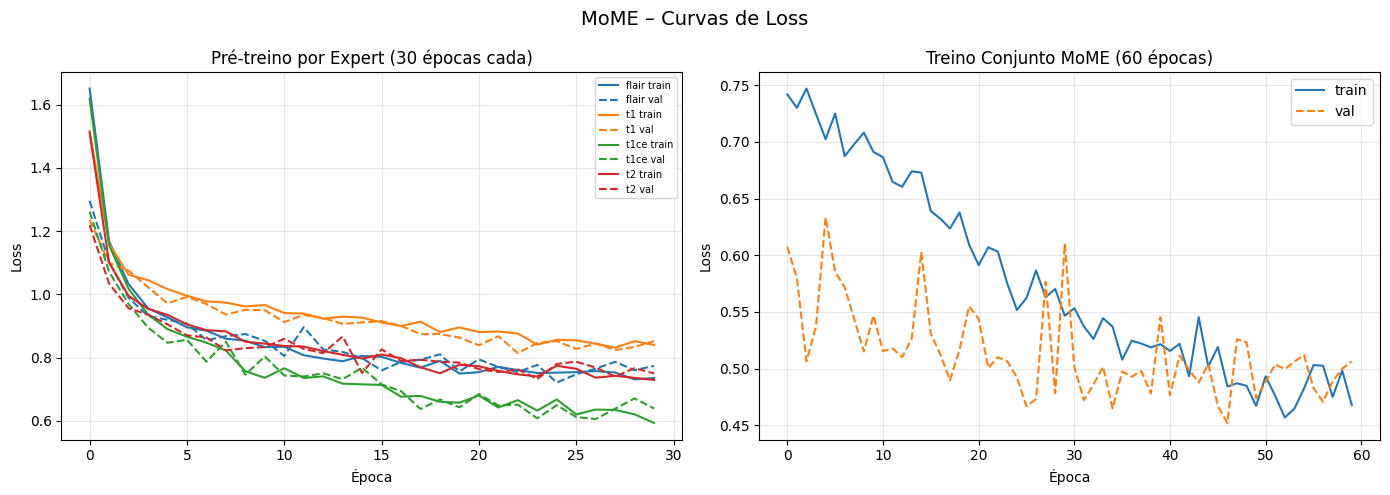


Paciente: BraTS20_Training_214 | split=test | z=70
Dice C1 (necrose):   0.6929
Dice C2 (edema):     0.9200
Dice ET (enhancing): 0.8897
Dice WT:             0.9578
Dice TC:             0.9166


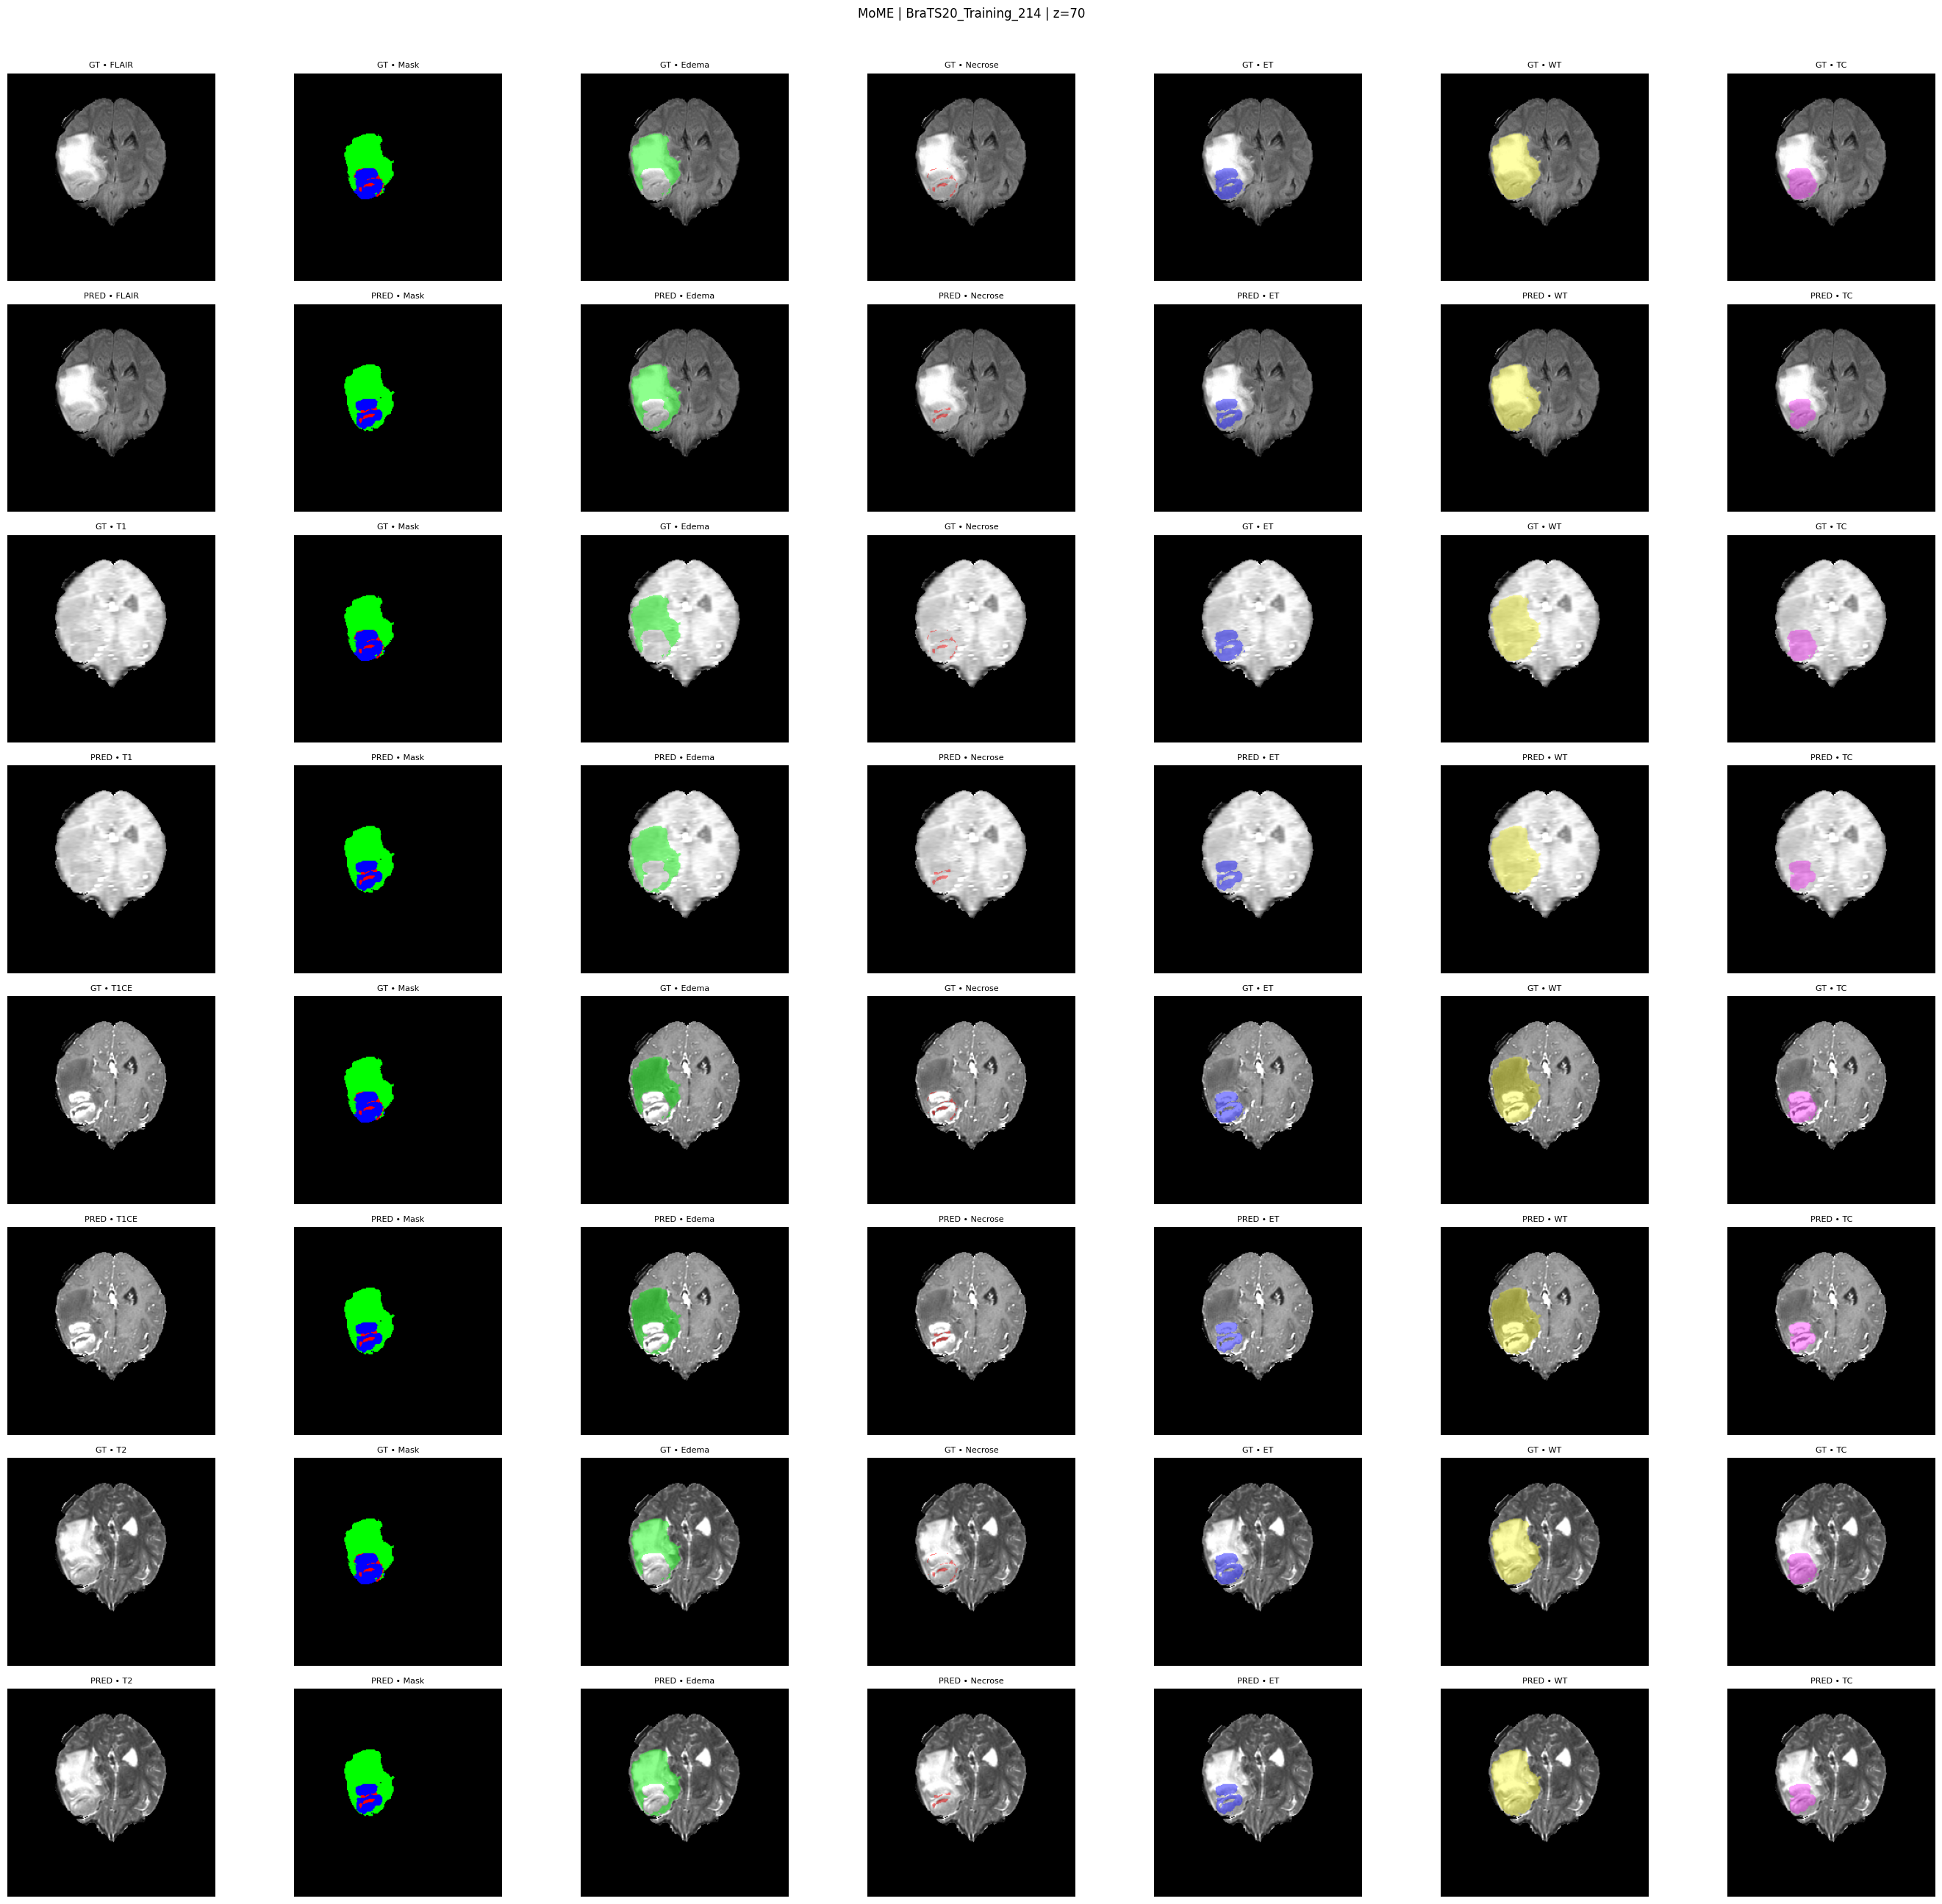

In [16]:
# ── 1. Instancia MoME ────────────────────────────────────────────────────────
model = MoME(
    n_experts=N_EXPERTS,
    n_cls=N_CLASSES,
    base_ch=BASE_CH,
    depth=DEPTH,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"\nMoME — {N_EXPERTS} experts | {n_params:.1f} M parâmetros")

# ── 2. Pré-treino individual ─────────────────────────────────────────────────
pretrain_hist = pretrain_experts(
    model, train_ids, val_ids,
    epochs=PRETRAIN_EPOCHS, save_dir=MOME_CKPT
)

# ── 3. Treino conjunto com curriculum learning ───────────────────────────────
#       load_all_expert_ckpts é chamado internamente
joint_hist = train_mome_joint(
    model, train_ids, val_ids,
    epochs=JOINT_EPOCHS, save_dir=MOME_CKPT
)

# ── 4. Carrega melhor checkpoint ─────────────────────────────────────────────
model.load_state_dict(
    torch.load(MOME_CKPT / "mome_best.pth", map_location=DEVICE))
print("Melhor modelo MoME carregado.")

# ── 5. Predição no conjunto de teste ────────────────────────────────────────
predict_test_set(model, test_ids, pred_dir=MOME_PRED)

# ── 6. Avaliação quantitativa ────────────────────────────────────────────────
df = evaluate_test_set(test_ids, pred_dir=MOME_PRED)

# ── 7. Curvas de loss ────────────────────────────────────────────────────────
plot_loss_curves(pretrain_hist, joint_hist)

# ── 8. Visualização qualitativa ──────────────────────────────────────────────
cid, z, dice_dict = plot_random_case_multimodal_gt_pred(
    test_ids, split_name="test",
    pred_dir=MOME_PRED, seed=None
)